# 4. The chromagram

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hale-T2/CHORD/blob/main/notebooks/04_chromagram.ipynb)

> **Paper ↔ code.** Section II-C: fold the CQT into 12 pitch classes and apply L2 normalisation with ε = machine epsilon (Eq. 10). Functions: `features.chroma_from_cqt`, `features.l2_normalize`, `features.cqt_chroma`, `features.stft_chroma`.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "Hale-T2/CHORD"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 4.1 From 84 bins to 12 pitch classes

A chroma vector answers one question per frame: *how much energy is there in each of the 12 pitch classes, regardless of octave?* Since the CQT's first bin is C1 and every 12 bins form an octave, bin $k$ belongs to pitch class $k \bmod 12$. Folding is a reshape and a sum.

CQT (84, 173) ->  chroma (12, 173)


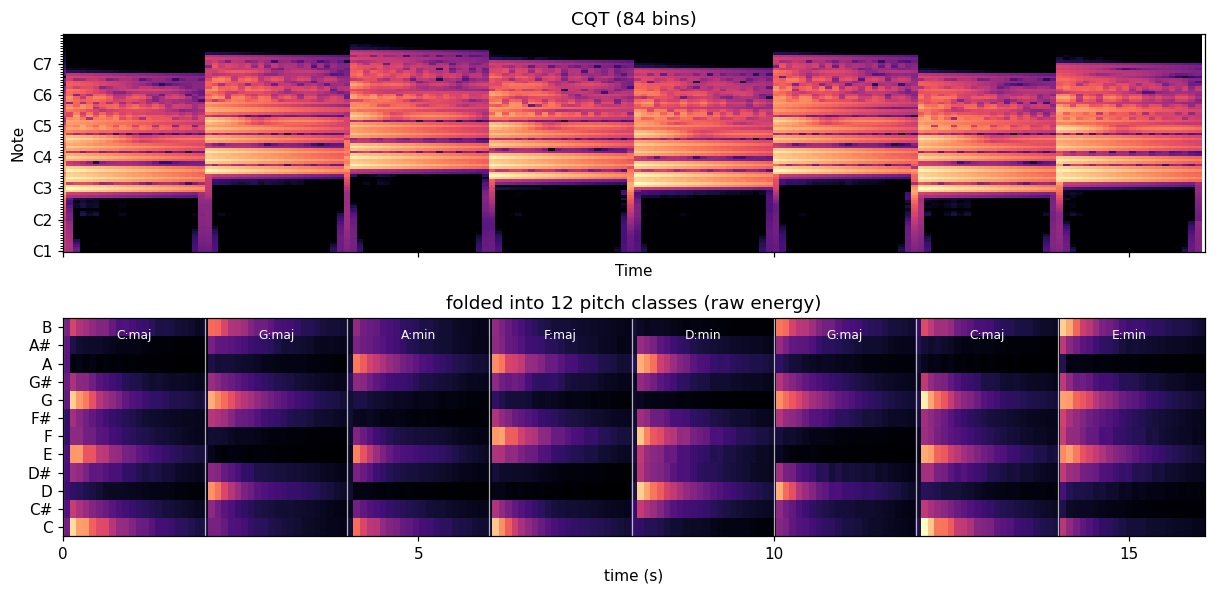

In [2]:
sr = features.SR
y, gt_intervals, gt_labels = synth.render_progression(synth.DEMO_PROGRESSION, 2.0, sr, timbre="piano")
C = features.cqt(y, sr)
chroma_raw = features.chroma_from_cqt(C)
print("CQT", C.shape, "->  chroma", chroma_raw.shape)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
times = features.frame_times(C.shape[1], sr)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(C), ref=np.max), sr=sr, hop_length=features.HOP_LENGTH, y_axis="cqt_note", x_axis="time", fmin=features.FMIN, ax=axes[0])
axes[0].set_title("CQT (84 bins)")
plots.plot_chroma(chroma_raw, times, ax=axes[1], title="folded into 12 pitch classes (raw energy)")
plots.overlay_segments(axes[1], gt_intervals, gt_labels)
plt.tight_layout(); plt.show()

`librosa` has a ready-made `chroma_cqt`; it is essentially the same fold (with its own normalisation and optional tuning estimation). Compare:

In [3]:
chroma_lib = librosa.feature.chroma_cqt(C=np.abs(C), bins_per_octave=12, n_octaves=features.N_OCTAVES, norm=None)
print("max abs difference between our fold and librosa.feature.chroma_cqt(norm=None):", np.abs(chroma_lib - chroma_raw).max().round(6))

max abs difference between our fold and librosa.feature.chroma_cqt(norm=None): 0.0


## 4.2 L2 normalisation (Eq. 10)

Loud and quiet passages should produce the same chord. The paper divides every chroma vector by its Euclidean length,

$$ x_\text{norm}[n] = \frac{X[n]}{\lVert X[n] \rVert_2 + \epsilon}, \qquad \epsilon \approx 2.22 \times 10^{-16}, \qquad (10) $$

where ε is the *machine epsilon* of double precision — the smallest number that, added to 1.0, still changes it. It only matters on perfectly silent frames, where it turns 0/0 into 0.

In [4]:
print("machine epsilon:", np.finfo(np.float64).eps, "  ->  ln(eps) =", np.log(np.finfo(np.float64).eps).round(2), "(the paper's 'log ε ≈ −36.04')")
chroma = features.l2_normalize(chroma_raw)
print("column norms after Eq. (10): min", np.linalg.norm(chroma, axis=0).min().round(6), "max", np.linalg.norm(chroma, axis=0).max().round(6))

silent = features.l2_normalize(np.zeros((12, 3)))
print("a silent frame stays finite:", silent[:, 0])

machine epsilon: 2.220446049250313e-16   ->  ln(eps) = -36.04 (the paper's 'log ε ≈ −36.04')
column norms after Eq. (10): min 1.0 max 1.0
a silent frame stays finite: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


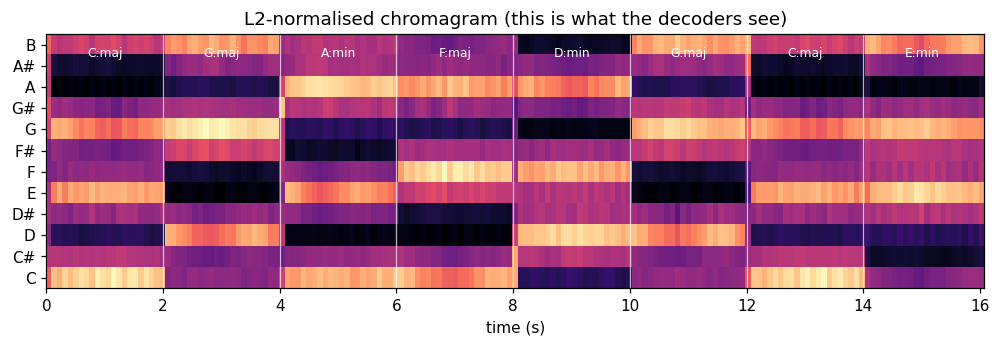

In [5]:
fig, ax = plt.subplots(figsize=(11, 3))
plots.plot_chroma(chroma, times, ax=ax, title="L2-normalised chromagram (this is what the decoders see)")
plots.overlay_segments(ax, gt_intervals, gt_labels)
plt.show()

Each chord shows three bright rows (its triad) plus faint overtone rows. Note the *decay* inside each chord: the piano note dies away, but normalisation keeps the *shape* of the vector constant — exactly the point of Eq. 10.

## 4.3 STFT chroma vs. CQT chroma

The paper argues for the CQT front end but reports only CQT results. Here is the direct comparison the reader has to imagine. Low notes are where the two differ most.

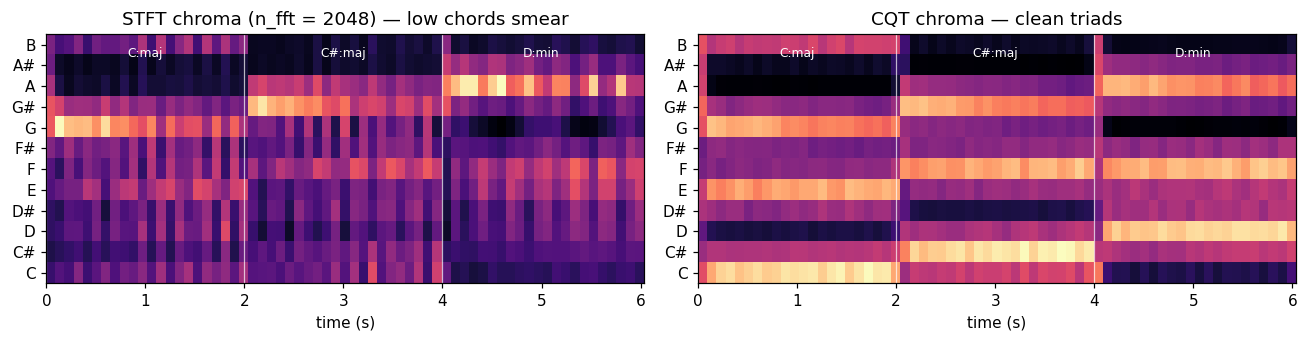

In [6]:
y_low, iv_low, lab_low = synth.render_progression(["C:maj", "C#:maj", "D:min"], 2.0, sr, timbre="organ", octave=2)
c_cqt, t_cqt = features.cqt_chroma(y_low, sr)
c_stft, t_stft = features.stft_chroma(y_low, sr, n_fft=2048)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
plots.plot_chroma(c_stft, t_stft, ax=axes[0], title="STFT chroma (n_fft = 2048) — low chords smear")
plots.overlay_segments(axes[0], iv_low, lab_low)
plots.plot_chroma(c_cqt, t_cqt, ax=axes[1], title="CQT chroma — clean triads")
plots.overlay_segments(axes[1], iv_low, lab_low)
plt.tight_layout(); plt.show()

## 4.4 What drums and a singer do to a chromagram

The paper's RWC-P failures are blamed on *percussive saturation* (drums leak into all 12 bins) and *vocal interference* (melody notes that are not chord tones). Our toy band can add both.

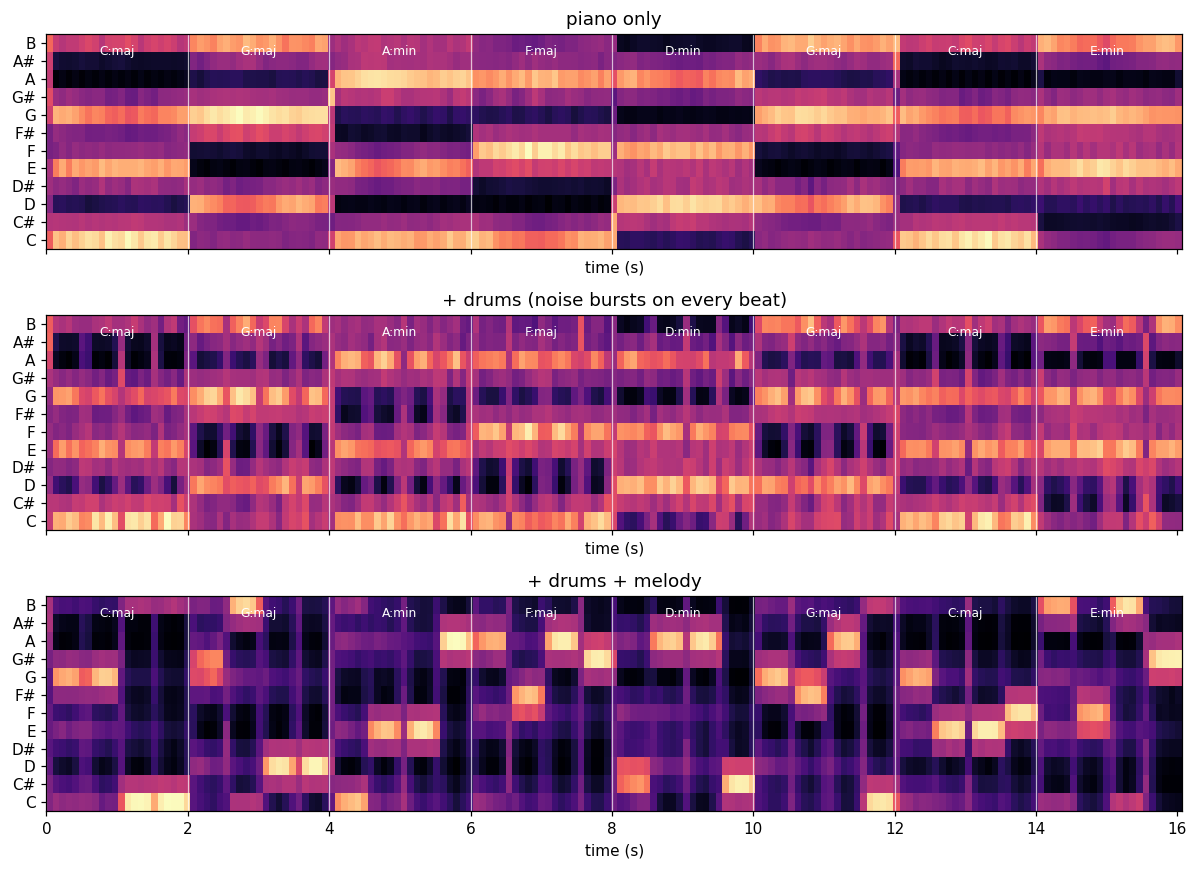

In [7]:
y_drums = synth.add_drums(y, sr, bpm=120, level=1.0)
y_band = synth.add_melody(y_drums, gt_intervals, gt_labels, sr)
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (sig, title) in zip(axes, [(y, "piano only"), (y_drums, "+ drums (noise bursts on every beat)"), (y_band, "+ drums + melody")]):
    c, t = features.cqt_chroma(sig, sr)
    plots.plot_chroma(c, t, ax=ax, title=title)
    plots.overlay_segments(ax, gt_intervals, gt_labels)
plt.tight_layout(); plt.show()
ipd.Audio(y_band, rate=sr)

Drum hits appear as vertical *columns* — energy in all pitch classes at once — and the melody adds bright rows that come and go inside a chord. Both make individual frames ambiguous. That ambiguity is the whole motivation for the two decoders in notebooks 5 and 6.

## Exercises

1. Beat-synchronous chroma: average the chroma frames between consecutive beats (`librosa.util.sync` with beat frames from `librosa.beat.beat_track`). Plot it for `y_band`. What did you gain and what did you lose?
2. Replace L2 by L1 normalisation (`chroma / chroma.sum(axis=0)`). Does the picture change? Does the cosine similarity in the next notebook care?
3. Reproduce the "one piano note looks like a major chord" effect from notebook 3 on the chromagram: render `["C:maj"]` with `synth.render_note` for a single C only and compare the two chroma vectors.